# Iris Species 

In [24]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV , StratifiedKFold
import warnings




In [25]:
df=pd.read_csv('../data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [27]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [28]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

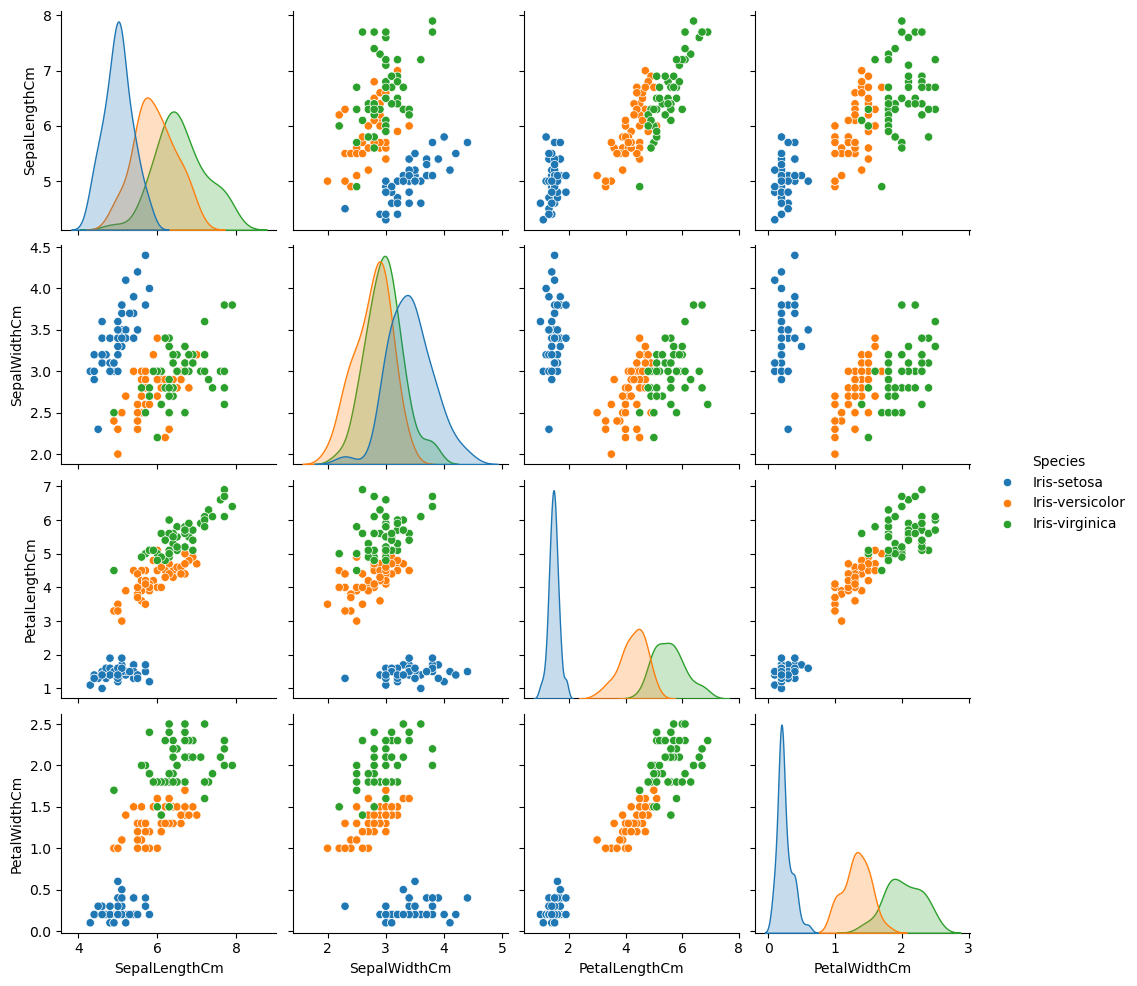

In [29]:
sns.pairplot(df.drop("Id", axis=1, errors="ignore"), hue="Species")
plt.show()


In [30]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

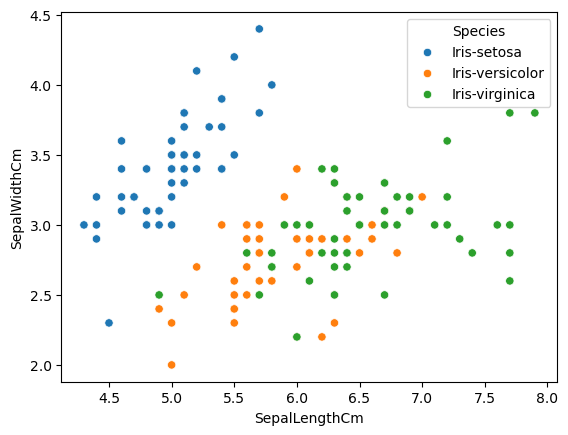

In [31]:
sns.scatterplot(x=df["SepalLengthCm"], y=df["SepalWidthCm"], hue=df["Species"])
plt.show()

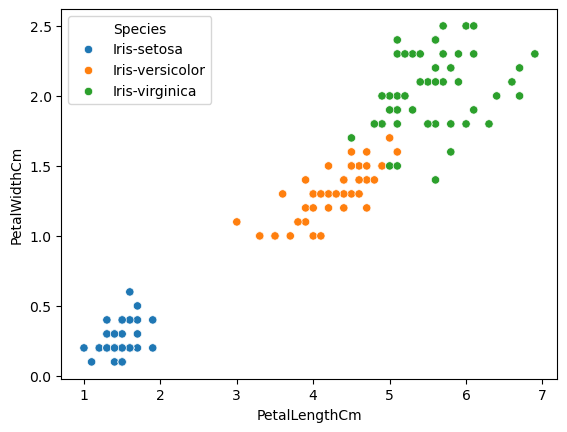

In [32]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

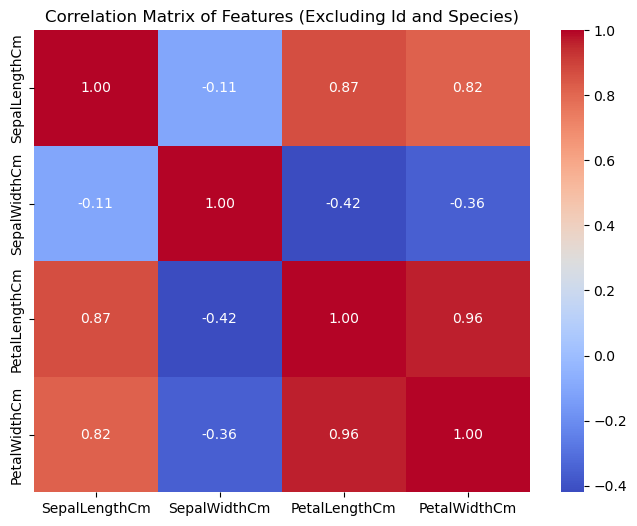

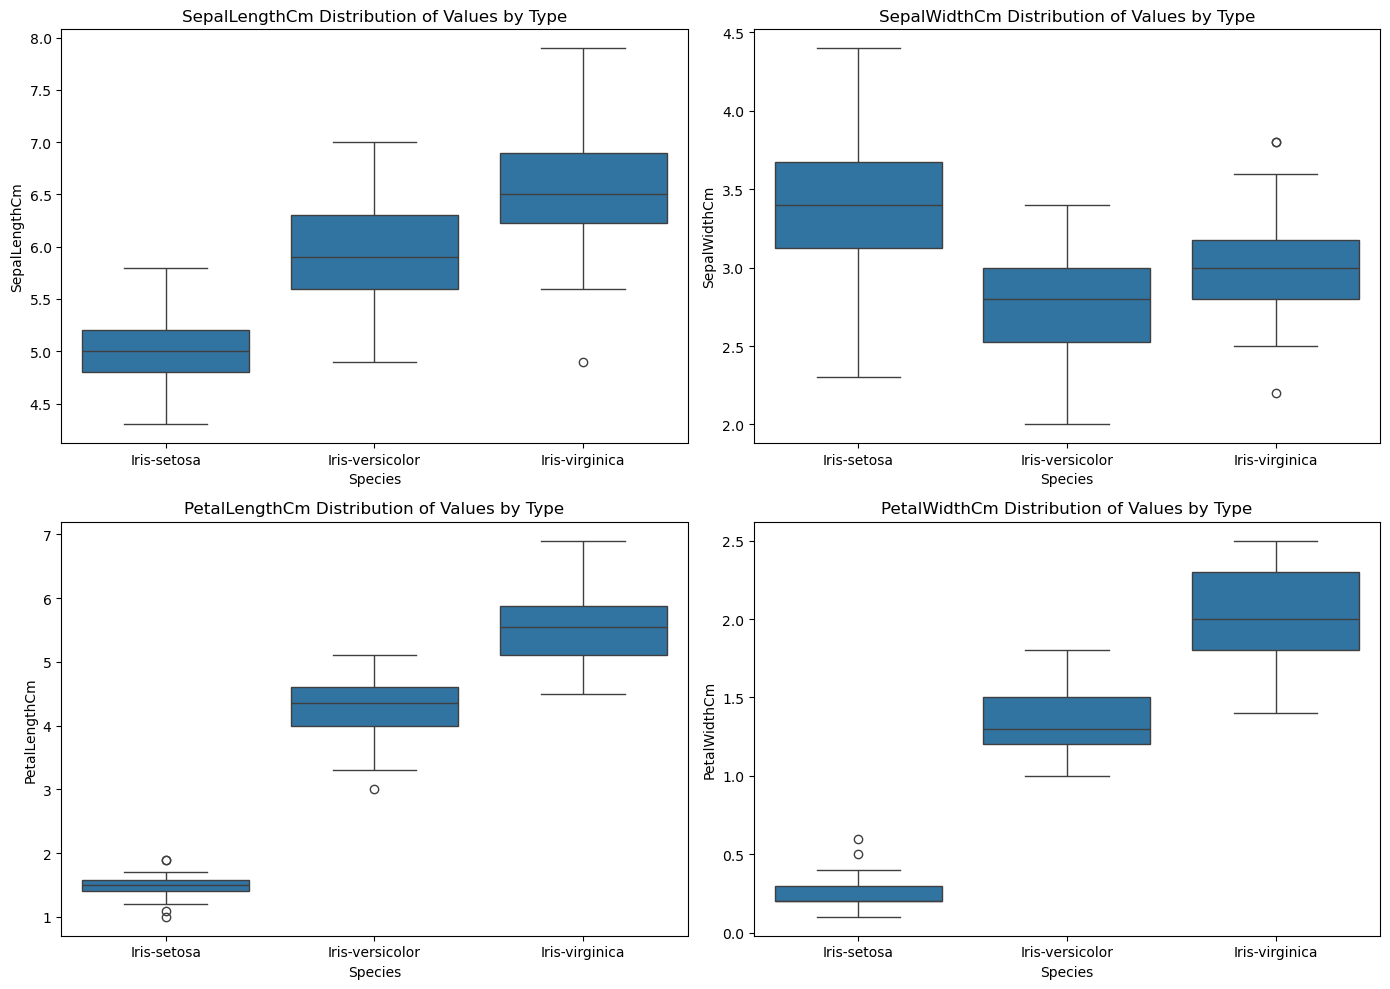

In [33]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(["Id", "Species"], axis=1, errors="ignore").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features (Excluding Id and Species)")
plt.show()

# Boxplot 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
for idx, feat in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x="Species", y=feat, data=df, ax=ax)
    ax.set_title(f"{feat} Distribution of Values ​​by Type")
plt.tight_layout()
plt.show()


In [34]:
df = df.drop("Id", axis=1)

In [35]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [36]:
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [37]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [38]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [39]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
## Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

In [42]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print( classification_report(y_pred, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [43]:
## Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("confusion matrix: \n", confusion_matrix(y_pred_lr, y_test))
print("accuracy score: ", accuracy_score(y_pred_lr, y_test))
print( classification_report(y_pred_lr, y_test))


confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [44]:
## SVC
svc=SVC()
svc.fit(X_train_scaled,y_train)
y_pred=svc.predict(X_test_scaled)
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print( classification_report(y_pred, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [45]:
# Logistic Regression (Hyperparameter Tuning)
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ["l1", "l2", "elasticnet"],
    'solver': ["newton-cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]
}

cv = StratifiedKFold()

grid_lr = GridSearchCV(estimator=lr , param_grid = lr_params, cv=cv, scoring="accuracy", n_jobs=-1)
warnings.filterwarnings("ignore")
grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters for Logistic Regression:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

# Evaluation
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_scaled)
print(f"\nScore: {accuracy_score(y_pred_lr_tuned, y_test):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_pred_lr_tuned, y_test))
print("\nClassification Report:\n", classification_report(y_pred_lr_tuned, y_test))


Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV Score: 0.9640316205533598

Score: 1.0000

Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [46]:
# SVC (Hyperparameter Tuning)
svc_params = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001]
}

grid_svc = GridSearchCV(SVC(random_state=42), svc_params, cv=5, scoring='accuracy')
grid_svc.fit(X_train_scaled, y_train)

print("Best Parameters for SVC:", grid_svc.best_params_)
print("Best CV Score:", grid_svc.best_score_)

# Evaluation
best_svc = grid_svc.best_estimator_
y_pred_svc_tuned = best_svc.predict(X_test_scaled)
print(f"\nScore: {accuracy_score(y_pred_svc_tuned, y_test):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_pred_svc_tuned, y_test))
print("\nClassification Report:\n", classification_report(y_pred_svc_tuned, y_test))


Best Parameters for SVC: {'C': 1, 'gamma': 1, 'kernel': 'linear'}
Best CV Score: 0.9640316205533598

Score: 1.0000

Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

